In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as pyp
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
os.chdir("C:\\Users\khush\\OneDrive\\Documents\\csv\\")
os.getcwd()

'C:\\Users\\khush\\OneDrive\\Documents\\csv'

In [43]:
readFile = pd.read_csv("crop_price_dataset.csv")
readFile

,month,commodity_name,avg_modal_price,avg_min_price,avg_max_price,state_name,district_name,calculationType,change
0,2025-03-01,Maize,2341.58,2191.23,2402.98,India,All,Monthly,-14.43
1,2025-02-01,Maize,2356.01,2202.35,2414.46,India,All,Monthly,-26.19
2,2025-01-01,Maize,2382.20,2221.31,2448.22,India,All,Monthly,53.42
3,2024-12-01,Maize,2328.78,2164.86,2411.66,India,All,Monthly,55.32
4,2024-11-01,Maize,2273.46,2077.63,2377.78,India,All,Monthly,35.48
...,...,...,...,...,...,...,...,...,...
2805,2010-05-01,Coconut,3093.35,2564.30,3600.61,India,All,Monthly,-33.62
2806,2010-04-01,Coconut,3126.97,2666.44,3594.63,India,All,Monthly,138.53
2807,2010-03-01,Coconut,2988.44,2561.90,3406.92,India,All,Monthly,-12757.26
2808,2010-02-01,Coconut,15745.70,11634.74,19899.66,India,All,Monthly,12576.70


In [44]:
# total number of rows and columns present..
readFile.shape

(2810, 9)

In [45]:
#total variables..
readFile.dtypes

month               object
commodity_name      object
avg_modal_price    float64
avg_min_price      float64
avg_max_price      float64
state_name          object
district_name       object
calculationType     object
change             float64
dtype: object

In [46]:
# basic info about the data..
readFile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   month            2810 non-null   object 
 1   commodity_name   2810 non-null   object 
 2   avg_modal_price  2810 non-null   float64
 3   avg_min_price    2810 non-null   float64
 4   avg_max_price    2810 non-null   float64
 5   state_name       2810 non-null   object 
 6   district_name    2810 non-null   object 
 7   calculationType  2810 non-null   object 
 8   change           2794 non-null   float64
dtypes: float64(4), object(5)
memory usage: 197.7+ KB


In [47]:
# in this on change have some null values..

readFile.describe()

,avg_modal_price,avg_min_price,avg_max_price,change
count,2810.000000,2810.000000,2810.000000,2794.000000
mean,4878.738327,4654.972292,5226.054630,21.227505
std,5217.404278,8586.774537,5931.616637,1606.987231
min,7.000000,5.000000,10.000000,-29221.430000
25%,1871.800000,1748.487500,1963.757500,-74.612500
50%,3347.715000,3106.315000,3539.950000,9.465000
75%,5530.377500,4992.290000,6005.230000,102.910000
max,45412.600000,377904.120000,76757.630000,31566.670000


In [48]:
readFile.isna().sum()  # change has 16 non null values..

month               0
commodity_name      0
avg_modal_price     0
avg_min_price       0
avg_max_price       0
state_name          0
district_name       0
calculationType     0
change             16
dtype: int64

In [49]:
# since column "change" have some null values we will fill it with median..
readFile["change"].fillna(readFile["change"].median(),inplace=True) 

In [50]:
# now checking
readFile.isna().sum() # so we can see no null values..

month              0
commodity_name     0
avg_modal_price    0
avg_min_price      0
avg_max_price      0
state_name         0
district_name      0
calculationType    0
change             0
dtype: int64

In [51]:
readFile.columns = readFile.columns.str.lower().str.replace("_","")

In [52]:
readFile.columns

Index(['month', 'commodityname', 'avgmodalprice', 'avgminprice', 'avgmaxprice',
       'statename', 'districtname', 'calculationtype', 'change'],
      dtype='object')

In [53]:
# diffrent of commodities in dataset..
commodities = readFile["commodityname"].unique()
commodities

array(['Maize', 'Wheat', 'Rice', 'Sugar', 'Cotton', 'Coffee', 'Tea',
       'Sugarcane', 'Sunflower', 'Jowar(Sorghum)', 'Millets',
       'Barley (Jau)', 'Ginger(Dry)', 'Turmeric', 'Groundnut', 'Coconut'],
      dtype=object)

In [54]:
len(commodities) # so there are 16 diffrent crops.

16

In [55]:
# checking which Indian states are included in the dataset..
states = readFile["statename"].unique()
states # so the prices are same across all the regions of India..

array(['India'], dtype=object)

In [56]:
# now visualizing relations among the variables.

# how crop monthly average prices are related..
# for this we need to extract first months and all crops..


In [57]:
readFile["month"] = pd.to_datetime(readFile["month"])
readFile["months"] = readFile["month"].dt.month

In [58]:
readFile["months"]

0        3
1        2
2        1
3       12
4       11
        ..
2805     5
2806     4
2807     3
2808     2
2809     1
Name: months, Length: 2810, dtype: int32

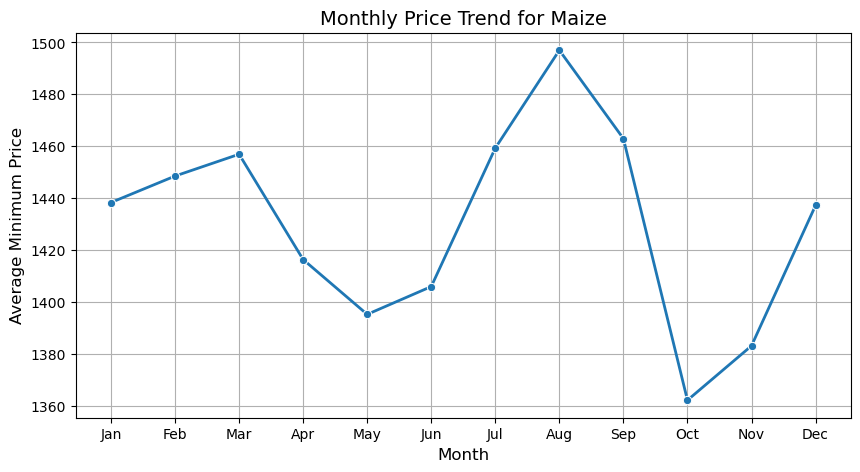

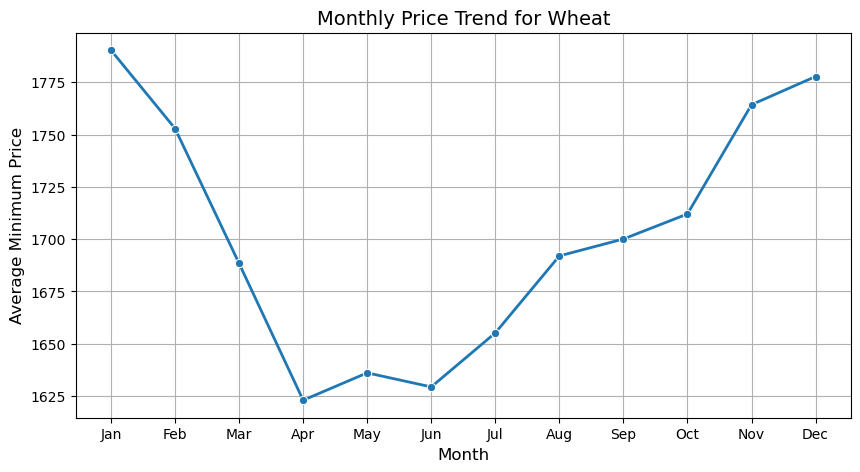

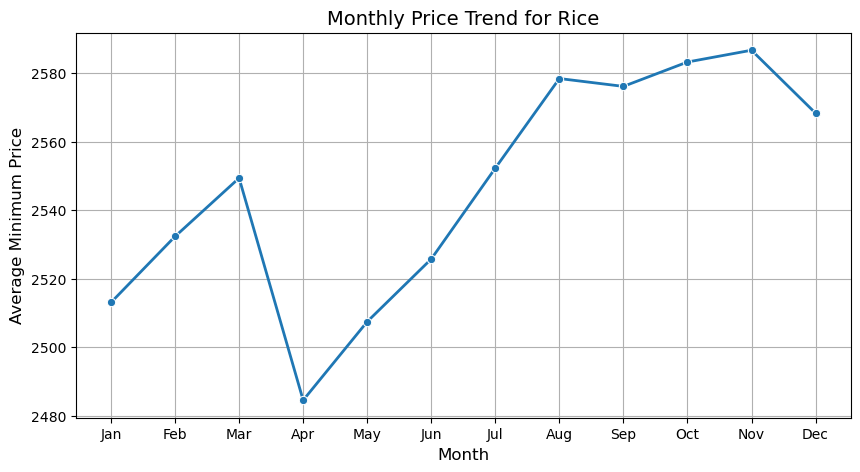

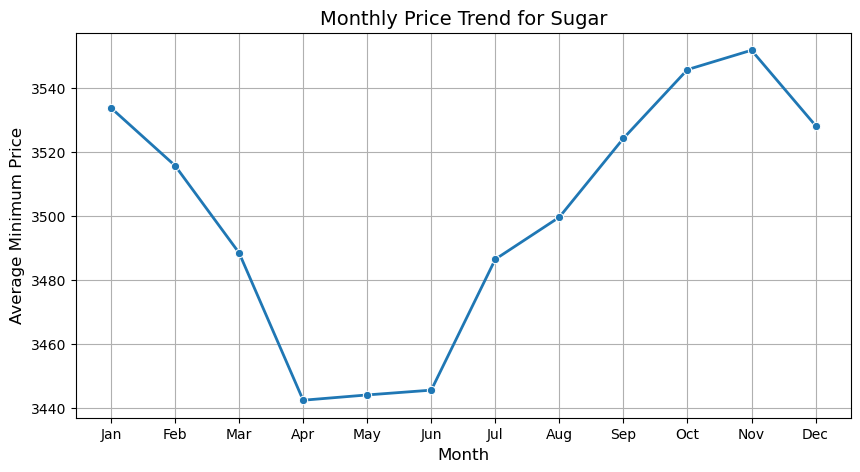

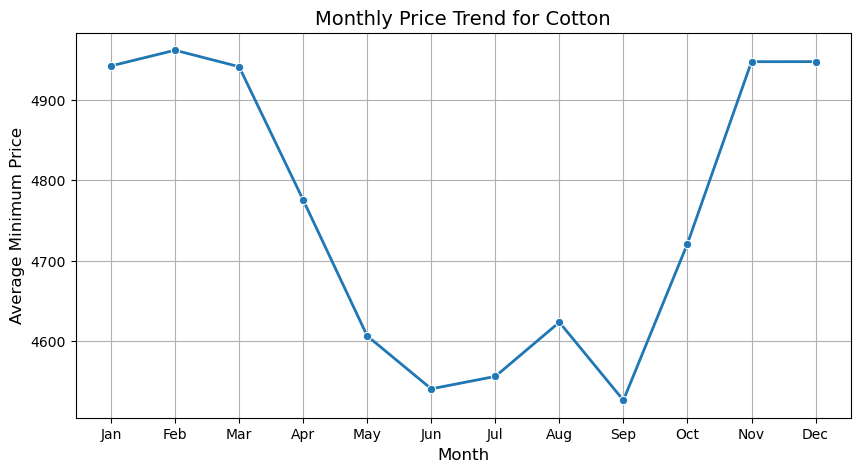

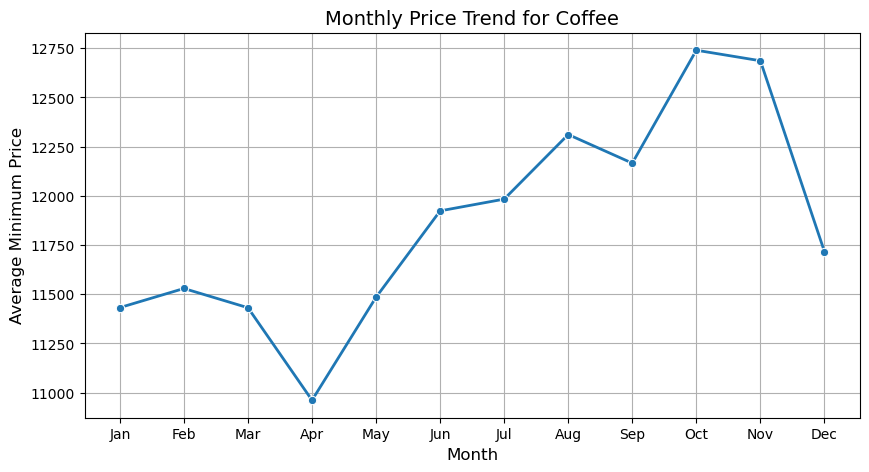

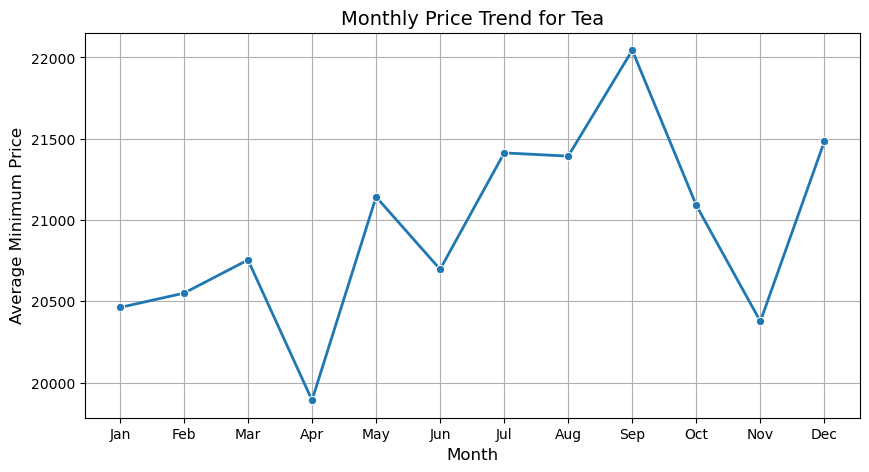

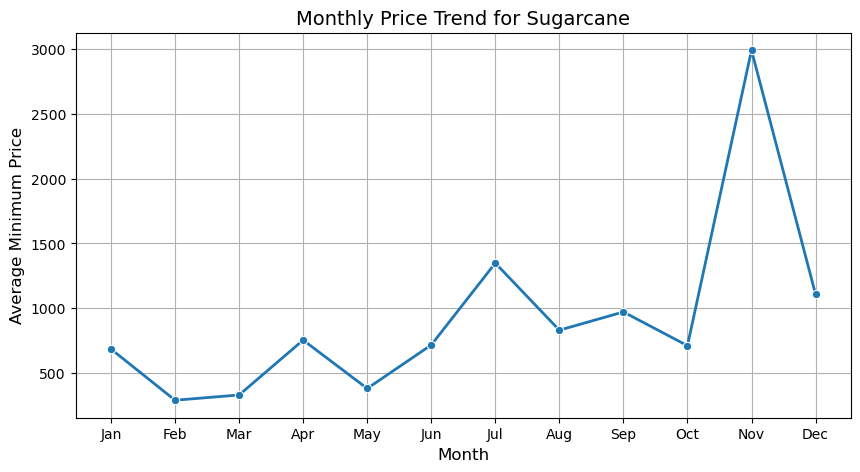

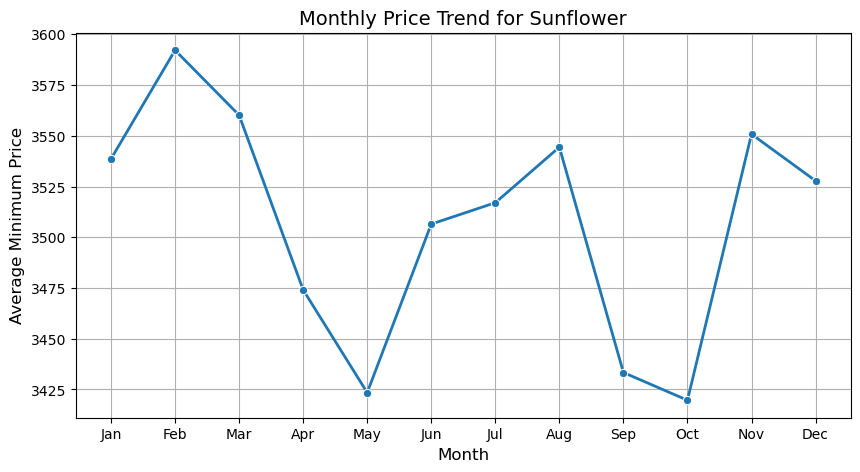

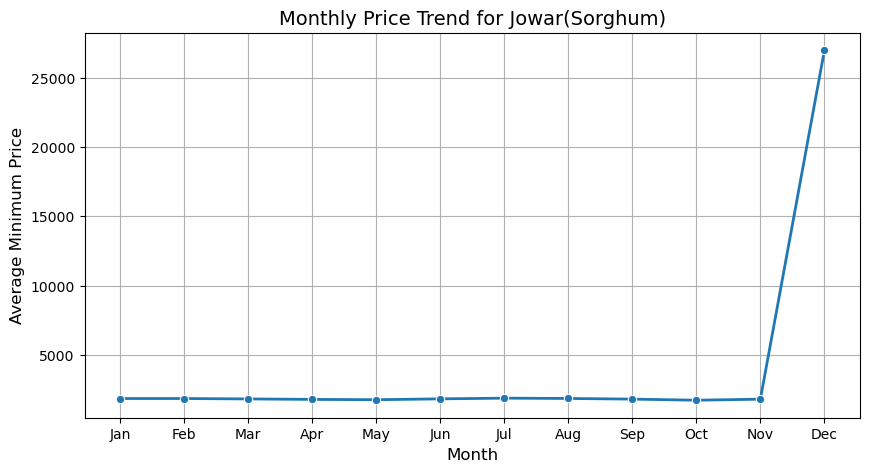

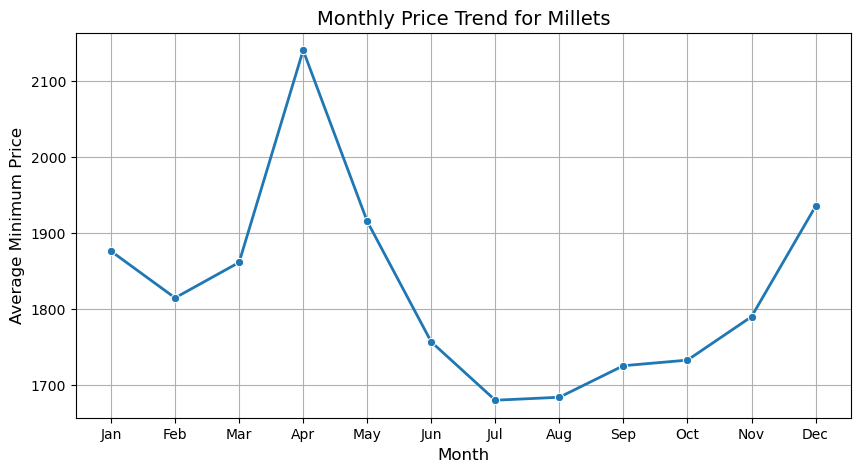

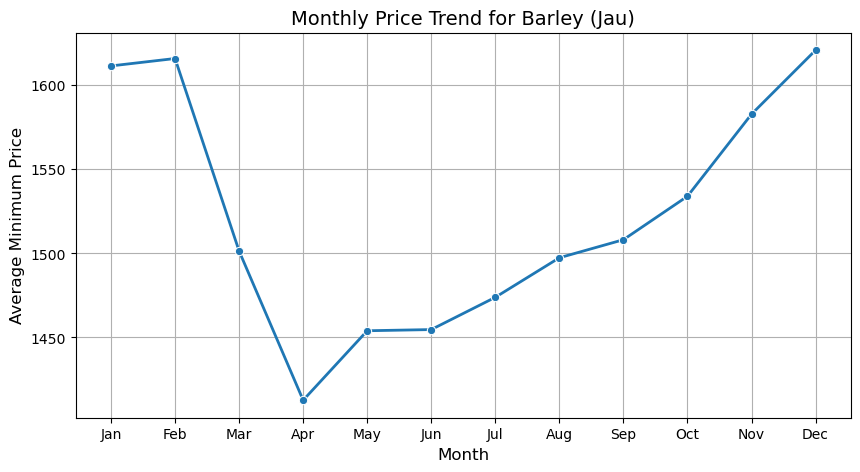

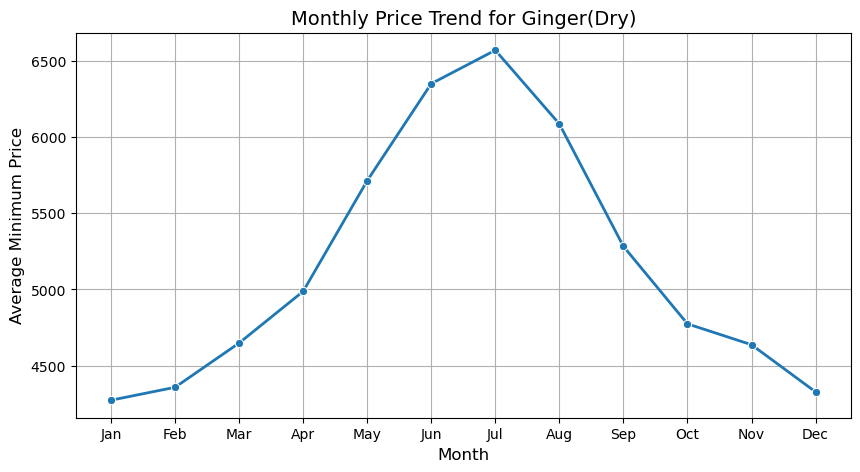

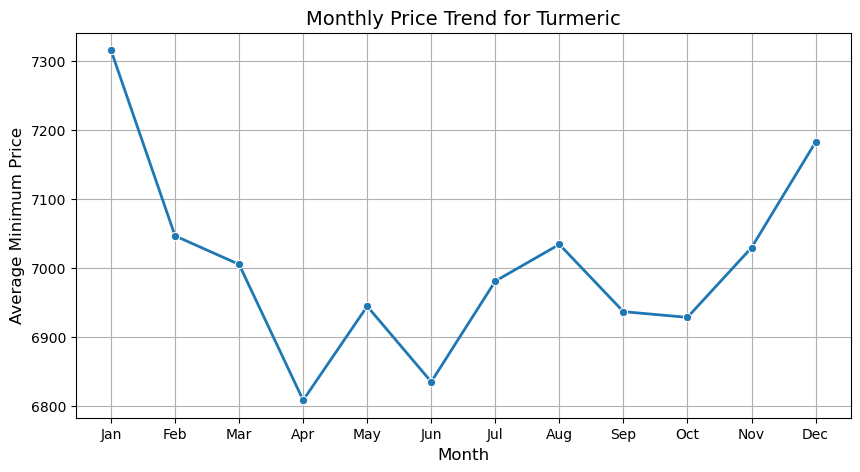

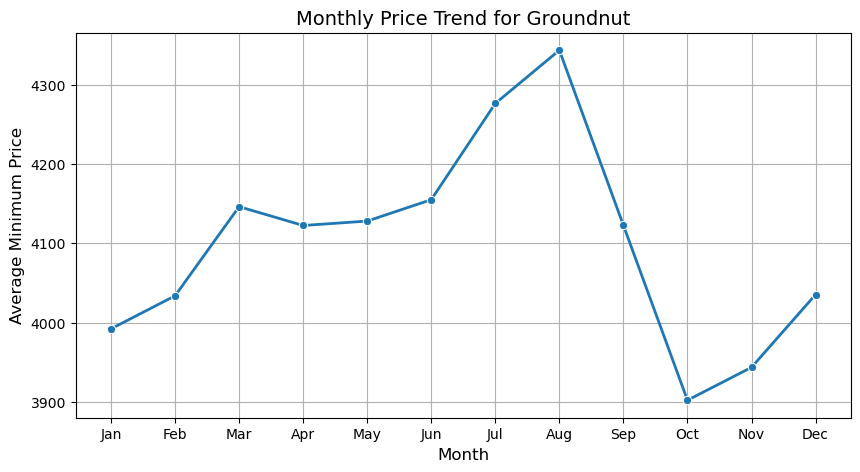

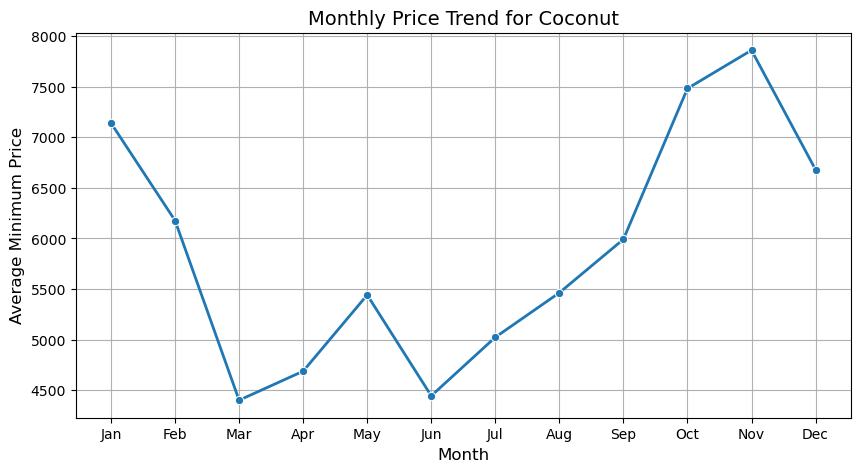

In [59]:
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}
for crop in commodities:
    crop_data = readFile[readFile["commodityname"] == crop] # for every crop there 
    monthly_prices = crop_data.groupby("months")["avgminprice"].mean().reset_index() #monthly avg minimum price
    monthly_prices["months"] = monthly_prices["months"].map(month_map)
    pyp.figure(figsize=(10,5))
    sns.lineplot(data=monthly_prices, x="months", y="avgminprice", marker="o",linewidth=2)
    pyp.xlabel("Month", fontsize=12)
    pyp.ylabel("Average Minimum Price", fontsize=12)
    pyp.title(f"Monthly Price Trend for {crop}",fontsize=14)
    pyp.grid()
    pyp.show()
    
    

In [60]:
# form above graph we can analyze that on which month the min price of crop is higher.
readFile["year"] = readFile["month"].dt.year

In [61]:
print("Data is from year:", readFile["year"].min(), "to", readFile["year"].max())

Data is from year: 2010 to 2025


C:\Users\khush\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\khush\AppData\Local\Temp\ipykernel_15428\1862527777.py:19: UserWarning: The figure layout has changed to tight
  pyp.tight_layout()


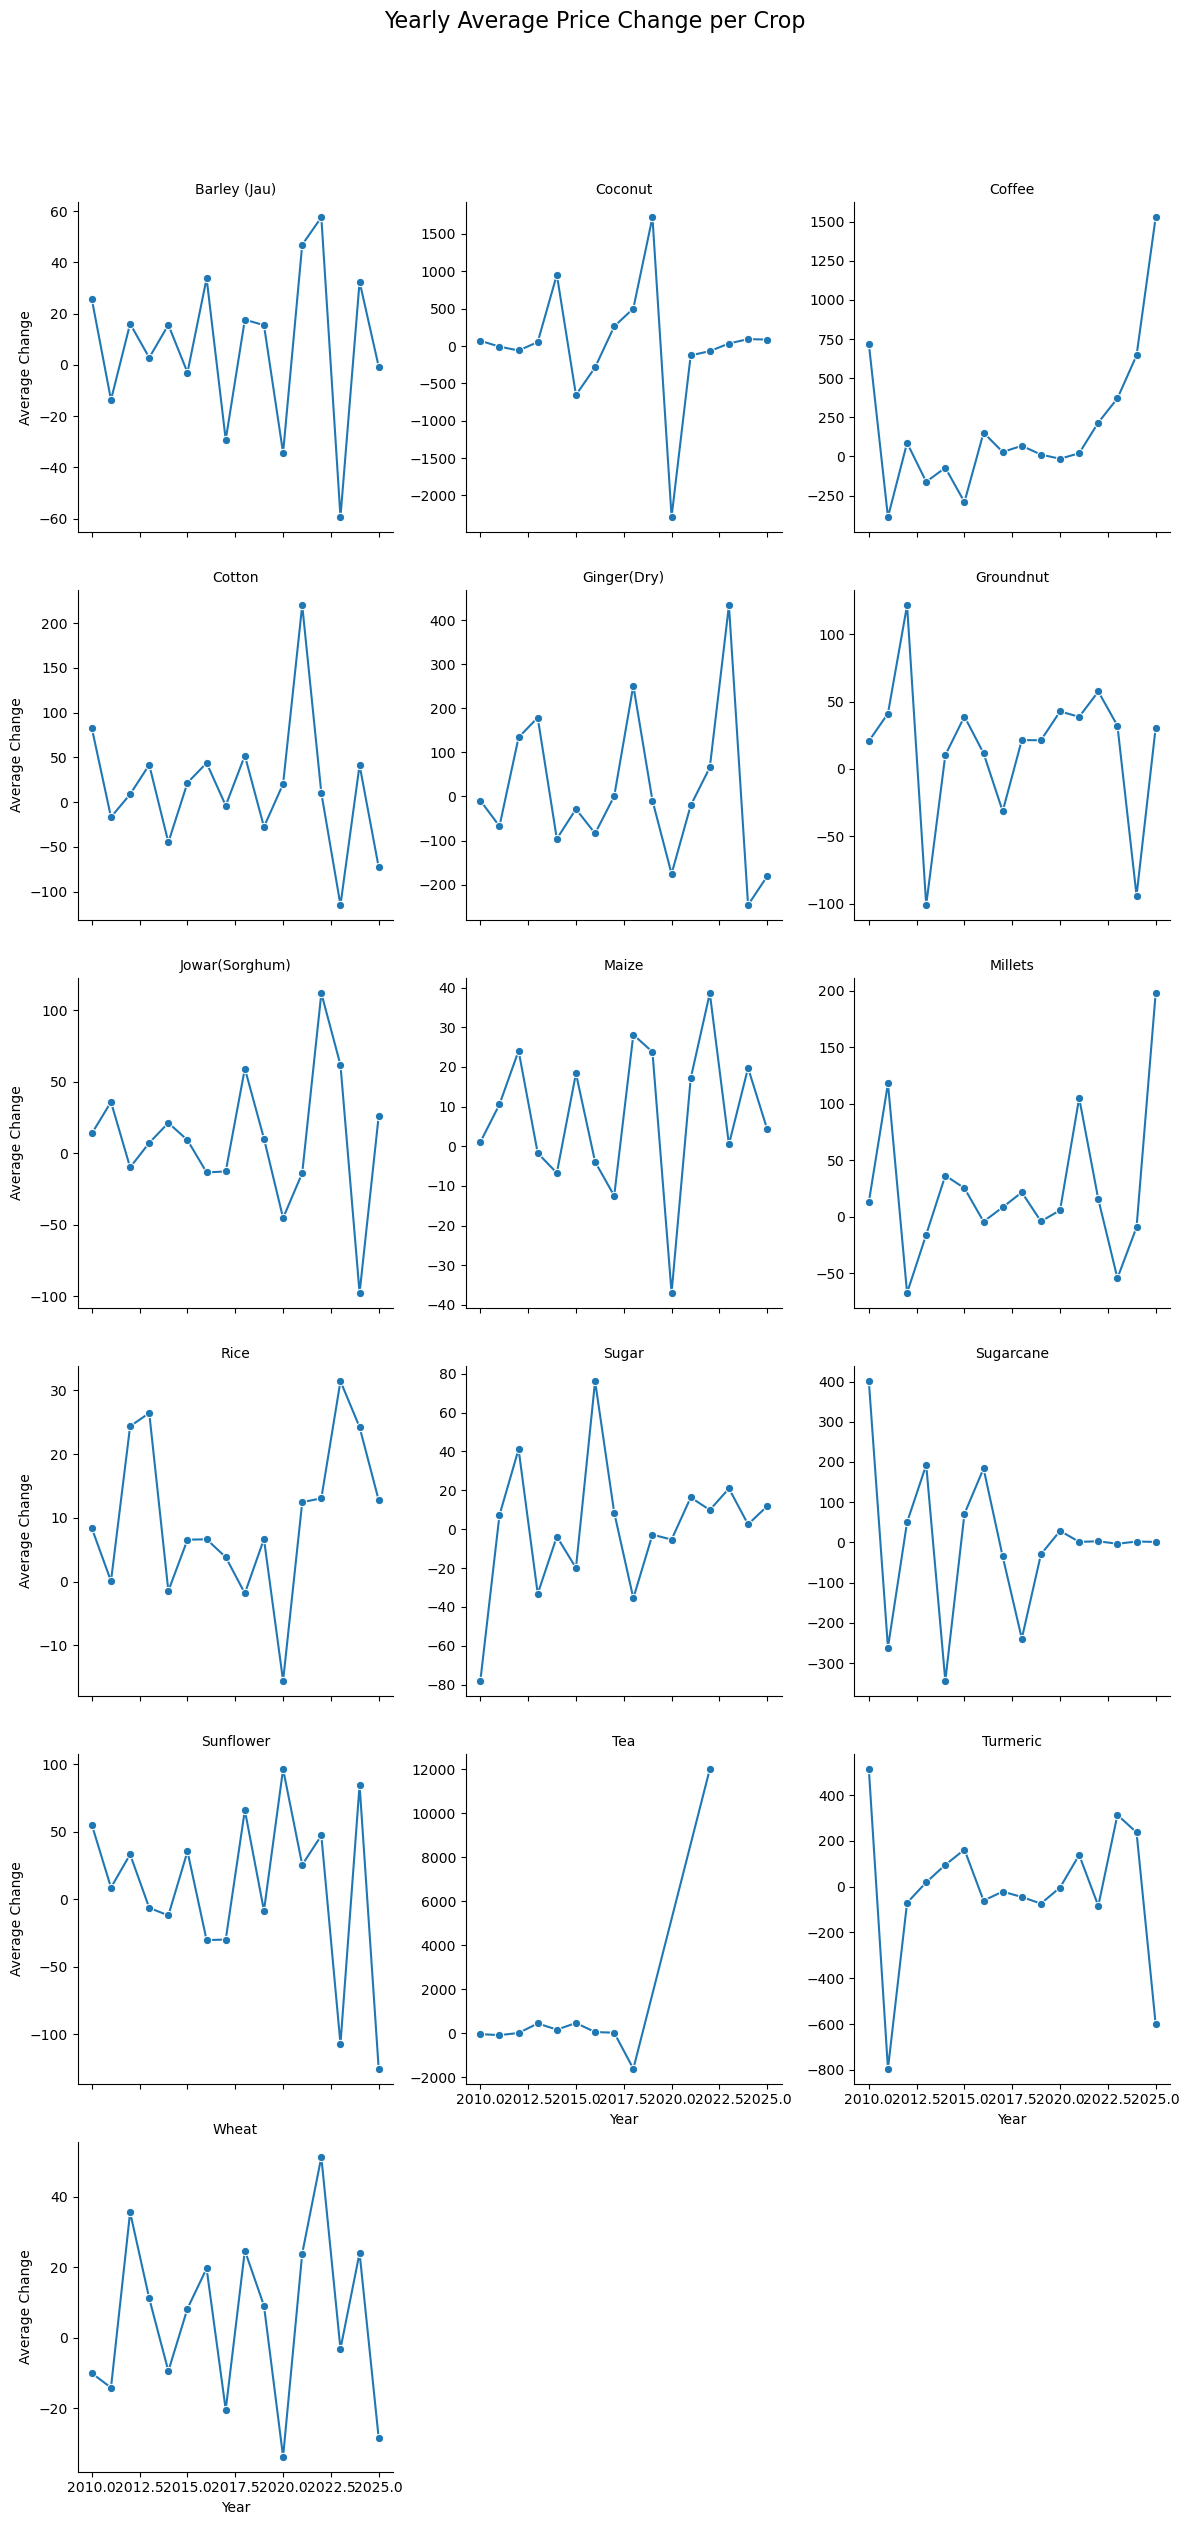

In [62]:
#so we have data of 15 years..

readFile["month"] = pd.to_datetime(readFile["month"])
readFile["year"] = readFile["month"].dt.year

# Group by crop and year
grouped = readFile.groupby(["commodityname", "year"])["change"].mean().reset_index()


top_crops = readFile["commodityname"].value_counts().head(16).index
grouped_top = grouped[grouped["commodityname"].isin(top_crops)]

# Create FacetGrid
g = sns.FacetGrid(grouped_top, col="commodityname", col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, "year", "change", marker="o")
g.set_titles("{col_name}")
g.set_axis_labels("Year", "Average Change")
g.fig.suptitle("Yearly Average Price Change per Crop", fontsize=16, y=1.05)
pyp.tight_layout()
pyp.show()

In [63]:

le_crop = LabelEncoder()
le_state = LabelEncoder()

readFile['commodity_encoded'] = le_crop.fit_transform(readFile['commodityname'])


X = readFile[['months', 'year', 'commodity_encoded',  'change']]
y = readFile['avgmodalprice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [66]:
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.9324835347568879
RMSE: 1946306.904945914


In [67]:
def recommend_best_month(crop_name, year=2025):
    months = list(range(1, 13))
    encoded_crop = le_crop.transform([crop_name])[0]
    
    input_data = pd.DataFrame({
        'months': months,  # <-- this should match training column name
        'year': [year]*12,
        'commodity_encoded': [encoded_crop]*12,
        'change': [0]*12  # or use average change if available
    })

    predicted_prices = model.predict(input_data)

    # Combine into DataFrame
    result = pd.DataFrame({
        'Month': months,
        'Predicted Price': predicted_prices
    })

    best_month = result.loc[result['Predicted Price'].idxmax()]
    print("\n Recommended Month to Sell:")
    print(f" Month: {best_month['Month']} →  Predicted Price: ₹{best_month['Predicted Price']:.2f}")
    return result

#  Example usage:
recommend_best_month("Rice")




 Recommended Month to Sell:
 Month: 12.0 →  Predicted Price: ₹3577.80


,Month,Predicted Price
0,1,3434.3106
1,2,3443.2046
2,3,3521.8739
3,4,3518.4710
4,5,3512.2442
5,6,3515.8087
6,7,3536.8600
7,8,3543.5311
8,9,3562.2633
9,10,3570.5054


In [40]:
import joblib
joblib.dump(model, "crop_price_model.pkl")
joblib.dump(le_crop,"crop_label_encoder.pkl")
joblib.dump(le_state,"state_label_encoder.pkl")



['state_label_encoder.pkl']

In [35]:
import pickle


with open("crop_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [71]:
readFile["commodityname"].unique()

array(['Maize', 'Wheat', 'Rice', 'Sugar', 'Cotton', 'Coffee', 'Tea',
       'Sugarcane', 'Sunflower', 'Jowar(Sorghum)', 'Millets',
       'Barley (Jau)', 'Ginger(Dry)', 'Turmeric', 'Groundnut', 'Coconut'],
      dtype=object)